(150, 4)
Accuracy: 0.9666666666666667
Loss:  0.09519895658198682


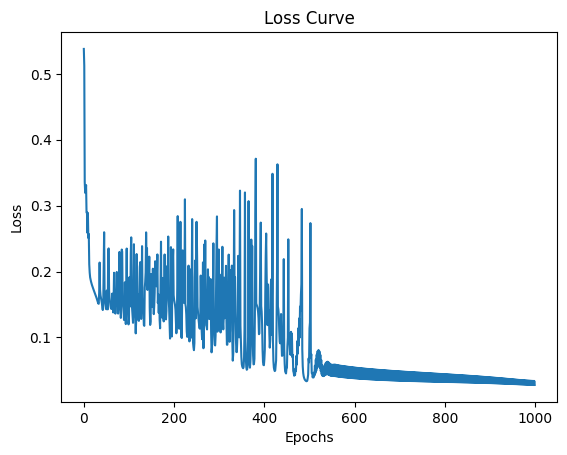

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

#traing single layer preptron from stratch 
# sigmoid funciton 
def sigmoid(x):
    return 1/(1+np.exp(-x))
# derivative of sigmoid funciton

def deri_sigmoid(x):
    return x*(1-x)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    #load data
data = load_iris()
X = data.data
y = data.target

# One-hot encoding for unorder data
def one_hot(y, num_classes):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

y = one_hot(y, 3)
#train test split data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

np.random.seed(42)
print(X.shape)
input_size = X.shape[1]   # 4 features
hidden_size = 8
output_size = 3
#initialise wweigghts and biases 
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

learning_rate = 0.01
epochs = 1000

losses = []

for epoch in range(epochs):
    #find errror
    z1 = np.dot(X_train, W1) + b1
    a1 = sigmoid(z1)#get sigmoin on hidden layer
    #first activation function is sigmoid adn second is softmax
    z2 = np.dot(a1, W2) + b2
    y_pred = softmax(z2) #get sigmoid for output layer
    #find loss that is cross entropy
    loss = -np.mean(y_train * np.log(y_pred + 1e-8))
    losses.append(loss)
    
    d_output = (y_pred - y_train)
    #change hidden layers perceptron
    dW2 = np.dot(a1.T, d_output)
    db2 = np.sum(d_output, axis=0, keepdims=True)

    d_hidden = np.dot(d_output, W2.T) * deri_sigmoid(a1)

    dW1 = np.dot(X_train.T, d_hidden)
    db1 = np.sum(d_hidden, axis=0, keepdims=True)

  #Update 
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

#testing on X_test data after traninug model on trained data
z1 = np.dot(X_test, W1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
y_pred = softmax(z2)
predictions = np.argmax(y_pred, axis=1)
actual = np.argmax(y_test, axis=1)
accuracy = np.mean(predictions == actual)
print("Accuracy:", accuracy)
print("Loss: ",np.mean(losses))
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()
# i check for epoches 100,1000 ,2000 with the increase of epoces loss will become smaller to smaler